In [2]:
import numpy as np
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import ultra_user.data_access.MyUltraFile as MyUltraFile
import ultra_user.data_access.Valdata as Valdata
import ultra_user.culling.UltraCull0 as UltraCull0
import spiceypy
import pandas as pd
import glob
import healpy as hp
import imap_processing.spice.time as spiceTime

droot = '/Users/demajr1/PycharmProjects/imap_processing/data/imap/validation/dps/'
valset = Valdata.Valdata(droot=droot)

pointings = valset.pointings
sensors = ['45','90']
spiceypy.furnsh('/Users/demajr1/PycharmProjects/imap_processing/data/imap/spice/sclk/imap_sclk_0054.tsc')
spiceypy.furnsh('/Users/demajr1/PycharmProjects/imap_processing/data/imap/spice/lsk/naif0012.tls')

# for structure only
sdcRoot = '/Users/demajr1/PycharmProjects/imap_processing/data/imap'
l1c = MyUltraFile.L1C(pointings[0],rootDir=sdcRoot).data
l1c_ebins = np.transpose([l1c['energy_bin_geometric_mean'] - l1c['energy_delta_minus'],
                          l1c['energy_bin_geometric_mean'] + l1c['energy_delta_plus']])
echans = l1c['energy_bin_geometric_mean'][0:-1]

Set of plots showing differences in total counts/pointing between SDC and out validation set

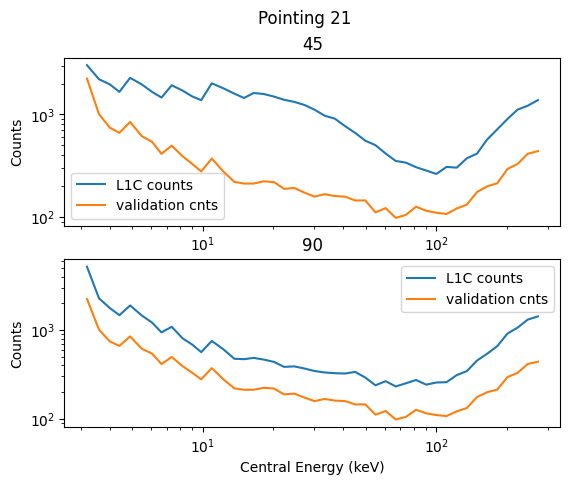

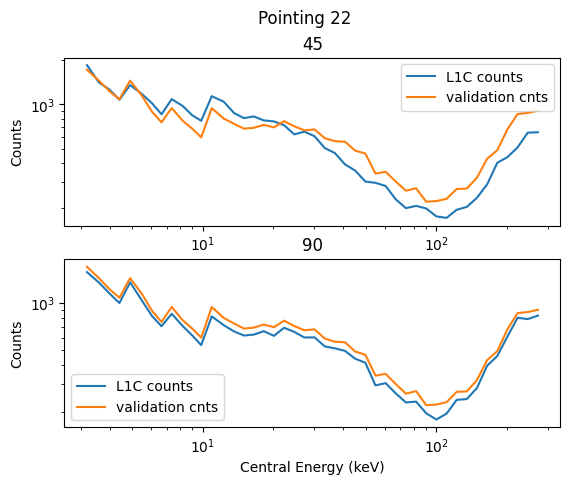

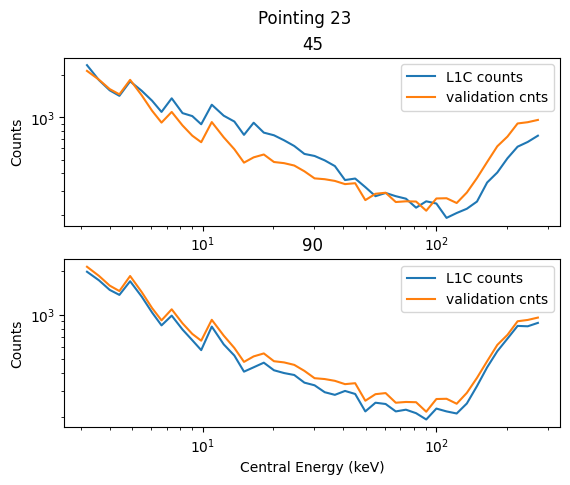

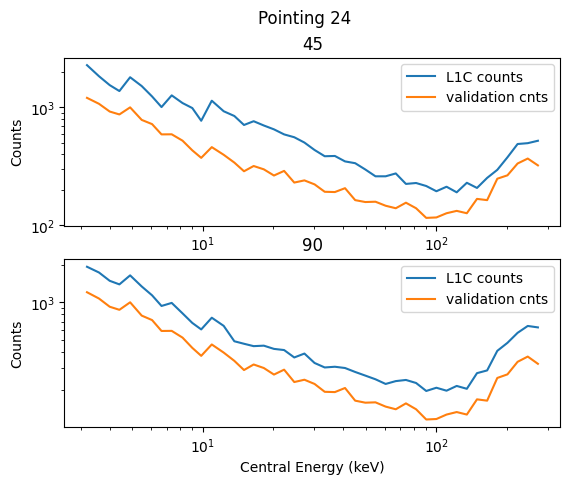

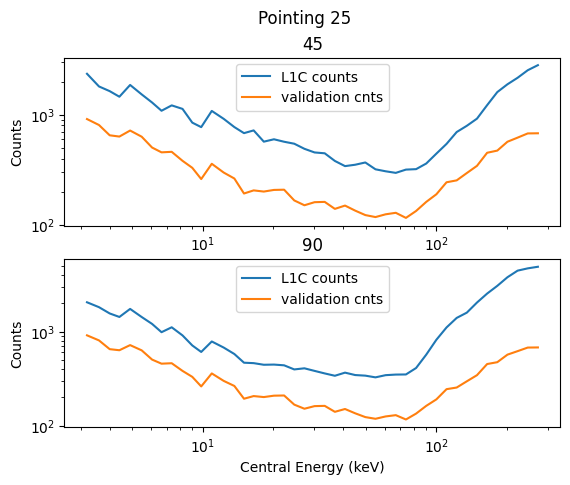

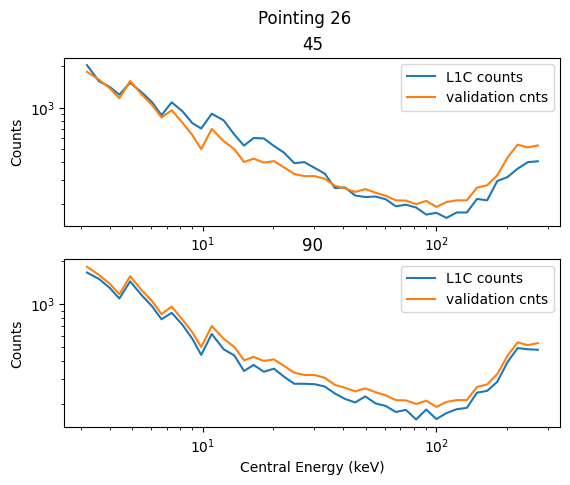

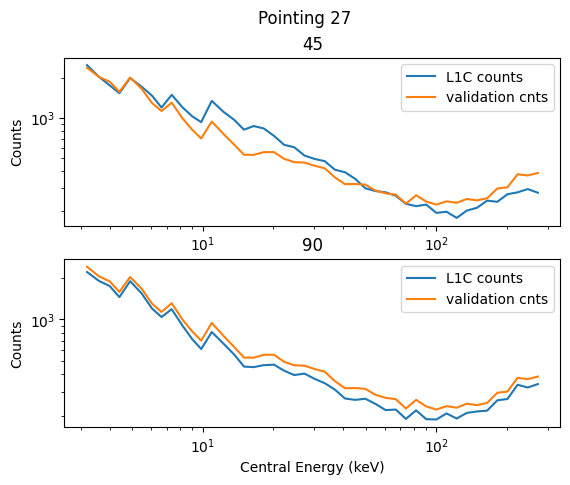

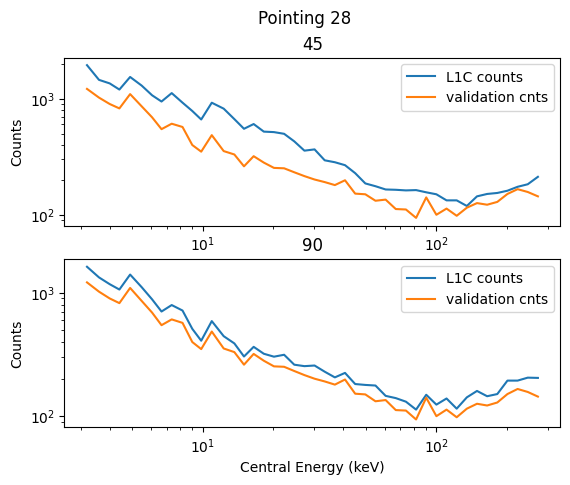

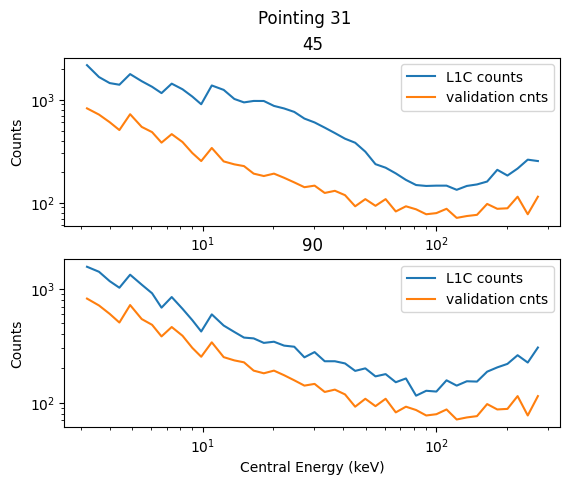

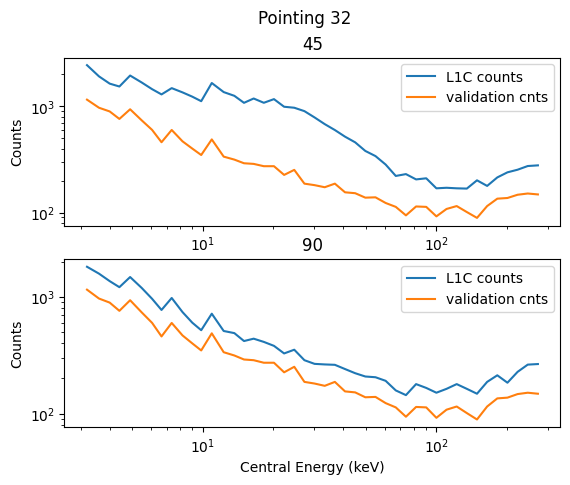

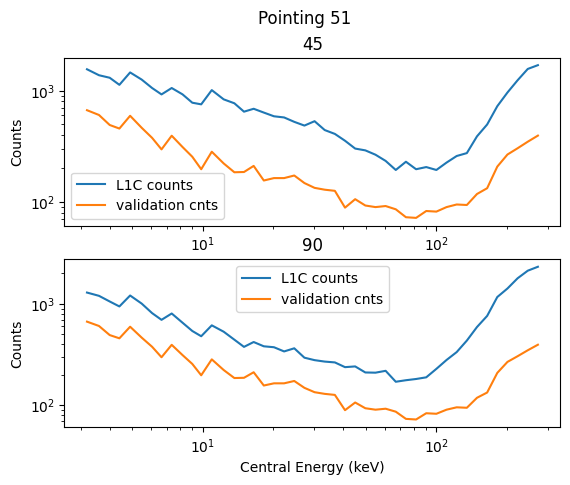

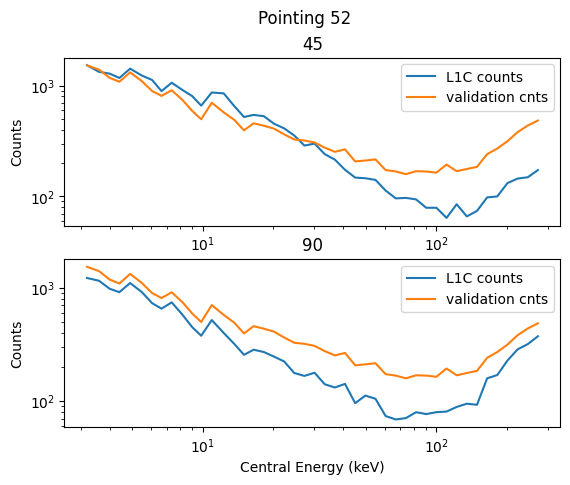

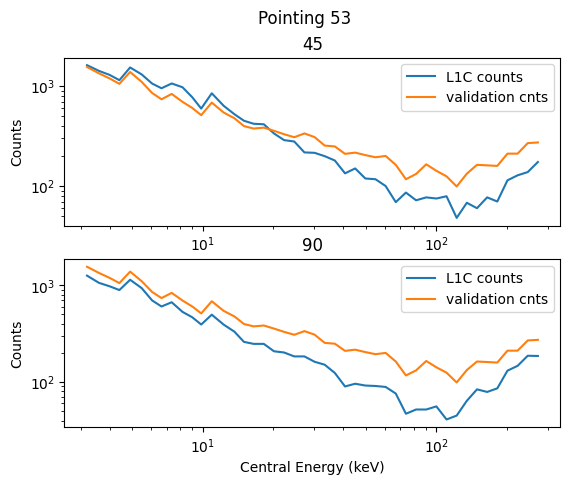

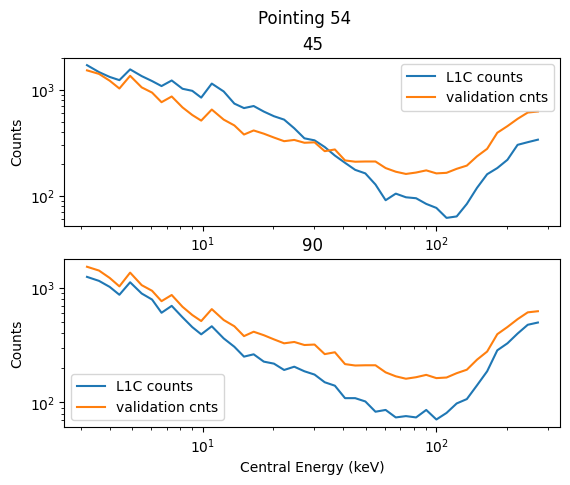

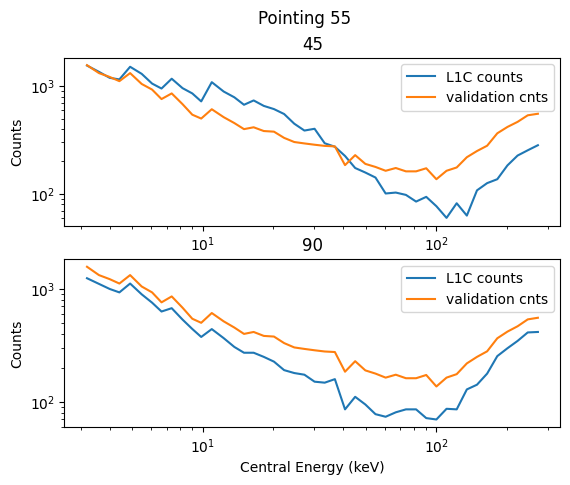

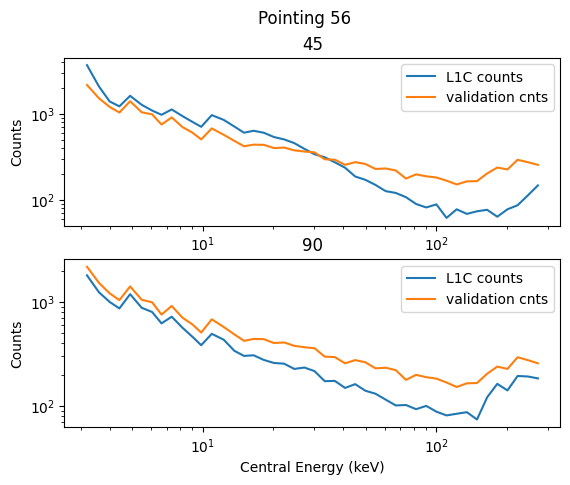

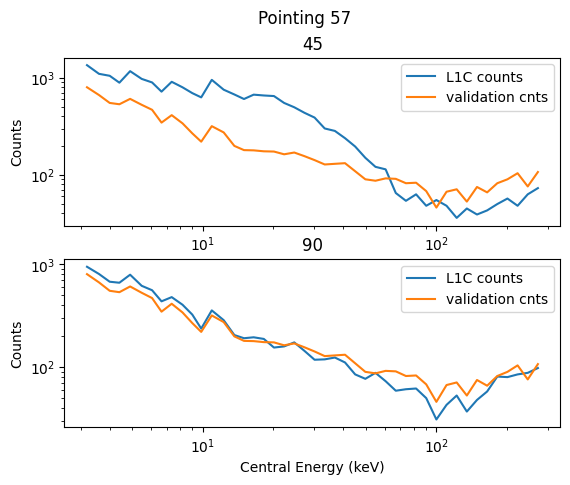

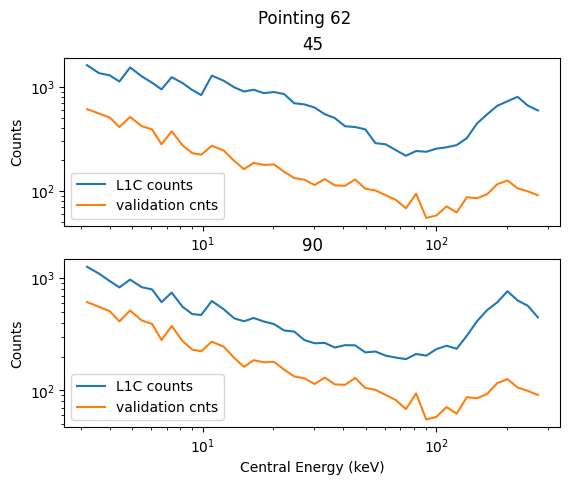

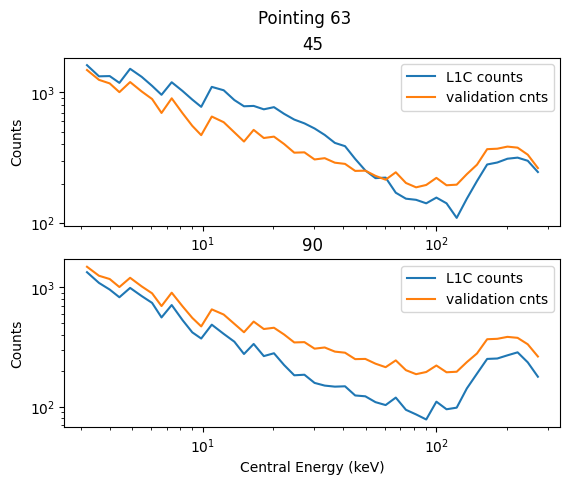

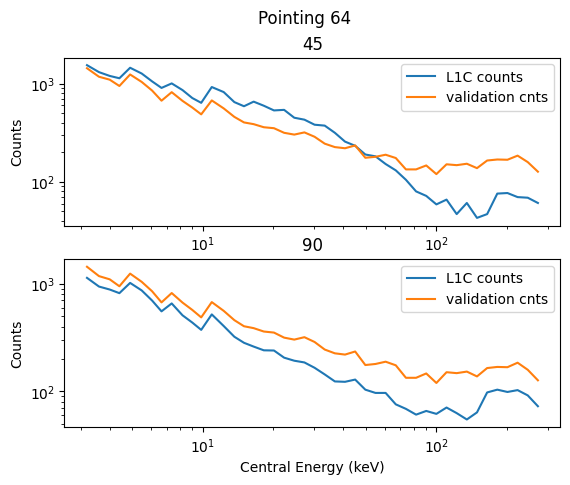

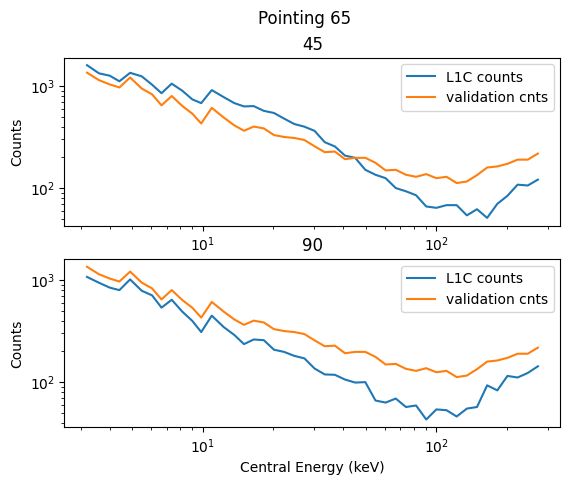

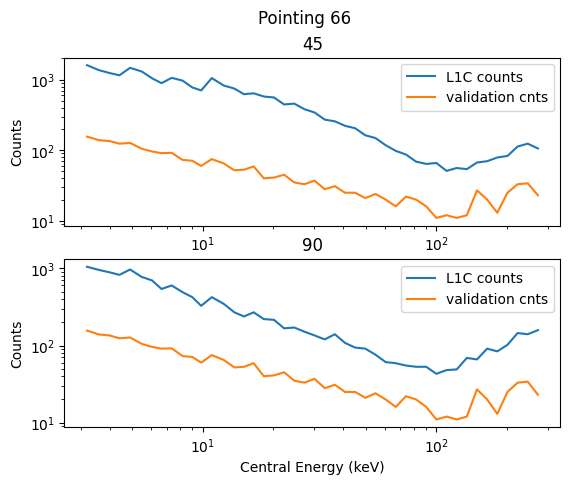

In [3]:
for pointing in pointings:
    fig, axs = plt.subplots(2)
    fig.suptitle(f"Pointing {pointing}")
    iplot=0
    for sensor in sensors:
        l1c = MyUltraFile.L1C(pointing, sensor=sensor,rootDir=sdcRoot).data
        tcounts_1c = np.sum(l1c['counts'], axis=2)[0]
        vcnts = np.sum(valset.get_pointing_data(pointing), axis=0)
        axs[iplot].plot(l1c['energy_bin_geometric_mean'][0:-1], tcounts_1c[0:-1], label='L1C counts')
        axs[iplot].plot(l1c['energy_bin_geometric_mean'][0:-1], vcnts[0:-1], label='validation cnts')
        axs[iplot].title.set_text(sensor)
        axs[iplot].set_xscale('log')
        axs[iplot].set_yscale('log')
        axs[iplot].set_ylabel('Counts')
        axs[iplot].set_xlabel('Central Energy (keV)')
        axs[iplot].legend()
        iplot = (iplot+1)%2
    plt.show()